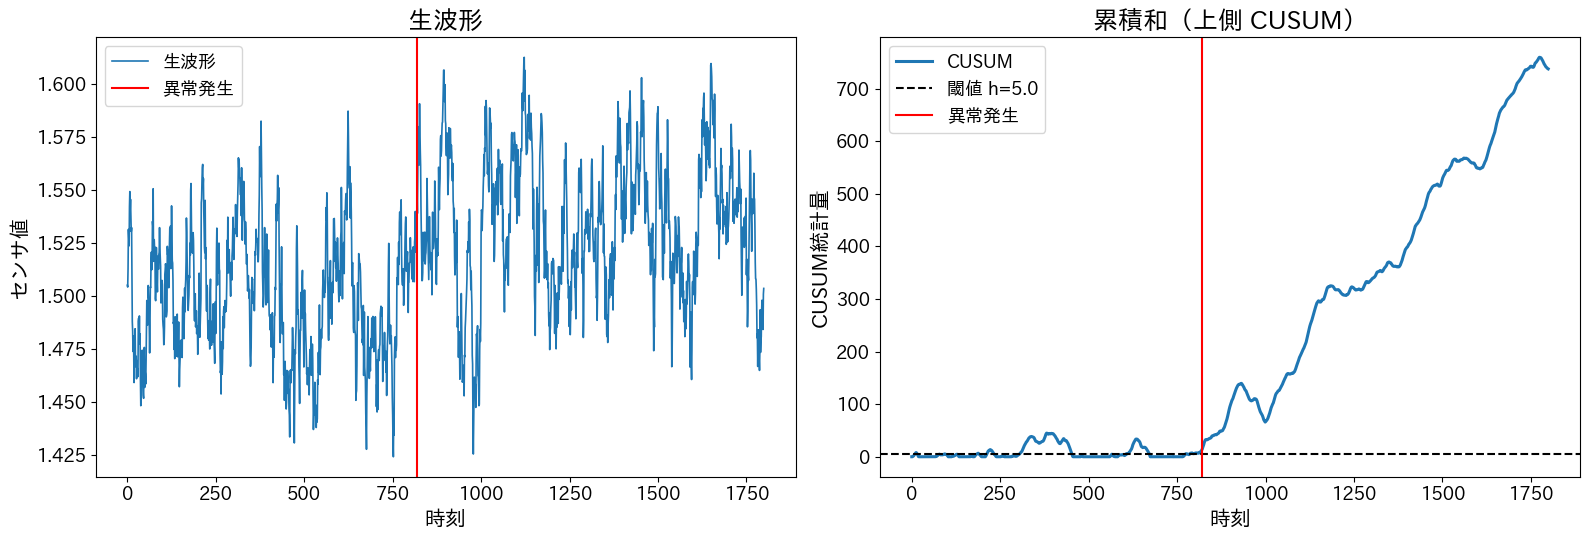

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# =============================
# 見た目の設定
# =============================
FIG_WIDTH = 16         # 図の横幅
FIG_HEIGHT = 5.5       # 図の縦幅

TITLE_SIZE = 18        # タイトル文字サイズ
LABEL_SIZE = 15        # 軸ラベル文字サイズ
TICK_SIZE = 13         # 目盛り文字サイズ
LEGEND_SIZE = 13       # 凡例文字サイズ

LINE_WIDTH_RAW = 1.2   # 生波形の線の太さ
LINE_WIDTH_CUSUM = 2.2 # CUSUMの線の太さ
LINE_WIDTH_REF = 1.5   # 基準線の太さ

# =============================
# サンプルデータ生成
# 想定:
# 最初は正常
# 途中からセンサ値が少し高めに出続ける
# ただしノイズがあるので、生波形だけでは分かりにくい
# =============================
np.random.seed(42)

n_total = 1800
change_point_true = 1000
time = np.arange(n_total)

# ゆっくりした運転変動
lowfreq = (
    0.015 * np.sin(2 * np.pi * time / 260)
    + 0.008 * np.sin(2 * np.pi * time / 90 + 0.7)
)

# 自己相関ノイズ
eps = np.random.normal(0, 0.012, n_total)
ar = np.zeros(n_total)
phi = 0.92
for i in range(1, n_total):
    ar[i] = phi * ar[i - 1] + eps[i]

baseline = 1.50

# 途中から少し高めのずれを追加
shift = np.zeros(n_total)
shift[change_point_true:] = 0.025

signal = baseline + lowfreq + ar + shift

# =============================
# 正常区間から基準平均と標準偏差を作る
# =============================
n_baseline = 800
mu0 = signal[:n_baseline].mean()
sigma0 = signal[:n_baseline].std(ddof=1)

# =============================
# 上側 CUSUM（片側累積和）
# C_t = max(0, C_{t-1} + z_t - k)
# =============================
z = (signal - mu0) / sigma0

k = 0.5
h = 5.0

cusum_pos = np.zeros(n_total)
for t in range(1, n_total):
    cusum_pos[t] = max(0.0, cusum_pos[t - 1] + z[t] - k)

alarm_indices = np.where(cusum_pos >= h)[0]
alarm_idx = int(alarm_indices[0]) if len(alarm_indices) > 0 else None

# =============================
# 可視化
# =============================
fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH, FIG_HEIGHT))

# ---- 左: 生波形
axes[0].plot(time, signal, linewidth=LINE_WIDTH_RAW, label="生波形")
# axes[0].axhline(mu0, linestyle="--", linewidth=LINE_WIDTH_REF, label="正常区間の平均", color="k")
axes[0].axvline(820, linestyle="-", linewidth=LINE_WIDTH_REF, label="異常発生", color="red")

axes[0].set_title("生波形", fontsize=TITLE_SIZE)
axes[0].set_xlabel("時刻", fontsize=LABEL_SIZE)
axes[0].set_ylabel("センサ値", fontsize=LABEL_SIZE)
axes[0].tick_params(axis="both", labelsize=TICK_SIZE)
axes[0].legend(fontsize=LEGEND_SIZE)

# ---- 右: CUSUM
axes[1].plot(time, cusum_pos, linewidth=LINE_WIDTH_CUSUM, label="CUSUM")
axes[1].axhline(h, linestyle="--", linewidth=LINE_WIDTH_REF, label=f"閾値 h={h}", color="k")
axes[1].axvline(820, linestyle="-", linewidth=LINE_WIDTH_REF, label="異常発生", color="red")

axes[1].set_title("累積和（上側 CUSUM）", fontsize=TITLE_SIZE)
axes[1].set_xlabel("時刻", fontsize=LABEL_SIZE)
axes[1].set_ylabel("CUSUM統計量", fontsize=LABEL_SIZE)
axes[1].tick_params(axis="both", labelsize=TICK_SIZE)
axes[1].legend(fontsize=LEGEND_SIZE)

plt.tight_layout()
plt.show()

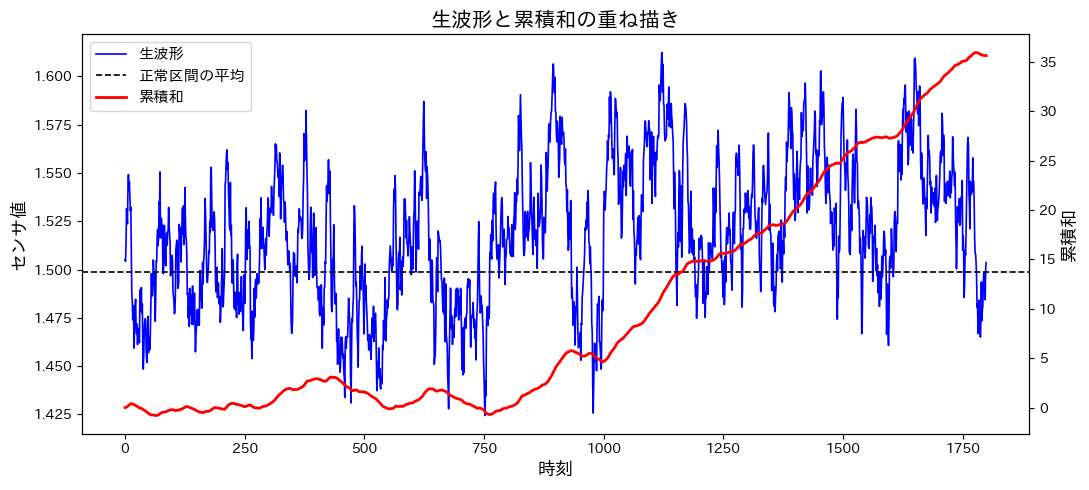

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# =========================================
# 1. サンプルデータ生成
#    想定:
#    - 最初は正常
#    - 途中からセンサ値が少し高めに出続ける
#    - ただしノイズがあるので、生波形だけでは分かりにくい
# =========================================
np.random.seed(42)
n_total = 1800
change_point_true = 1000   # 異常発生位置
time = np.arange(n_total)
# ゆっくりした運転変動
lowfreq = (
    0.015 * np.sin(2 * np.pi * time / 260)
    + 0.008 * np.sin(2 * np.pi * time / 90 + 0.7)
)
# 自己相関ノイズ
eps = np.random.normal(0, 0.012, n_total)
ar = np.zeros(n_total)
phi = 0.92
for i in range(1, n_total):
    ar[i] = phi * ar[i - 1] + eps[i]
# ベース信号
baseline = 1.50
# 異常発生後は少し高めにずらす
shift = np.zeros(n_total)
shift[change_point_true:] = 0.025
# 最終的なセンサ波形
signal = baseline + lowfreq + ar + shift

# =========================================
# 2. 正常区間から基準平均を作る
# =========================================
n_baseline = 800
mu0 = signal[:n_baseline].mean()

# =========================================
# 3. 説明の式そのままの累積和
#    S_t = sum_{i=1}^t (x_i - mu0)
# =========================================
cusum = np.cumsum(signal - mu0)

# =========================================
# 4. 生波形と累積和を1枚に重ねて表示
#    左軸: 生波形
#    右軸: 累積和
# =========================================
fig, ax1 = plt.subplots(figsize=(11, 5))

# 左軸に生波形
ax1.plot(time, signal, linewidth=1.2, label="生波形", color="blue")
ax1.axhline(mu0, linestyle="--", linewidth=1.2, color="k", label="正常区間の平均")
ax1.set_xlabel("時刻", fontsize=13)
ax1.set_ylabel("センサ値", fontsize=13)
ax1.set_title("生波形と累積和の重ね描き", fontsize=15)

# 右軸に累積和
ax2 = ax1.twinx()
ax2.plot(time, cusum, linewidth=2.0, label="累積和", color="red")
ax2.set_ylabel("累積和", fontsize=13)

# 凡例をまとめる
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=11)

plt.tight_layout()
plt.show()

C:\Users\tsenz\AppData\Local\Temp\ipykernel_9220\175933343.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
C:\Users\tsenz\AppData\Local\Temp\ipykernel_9220\175933343.py:114: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


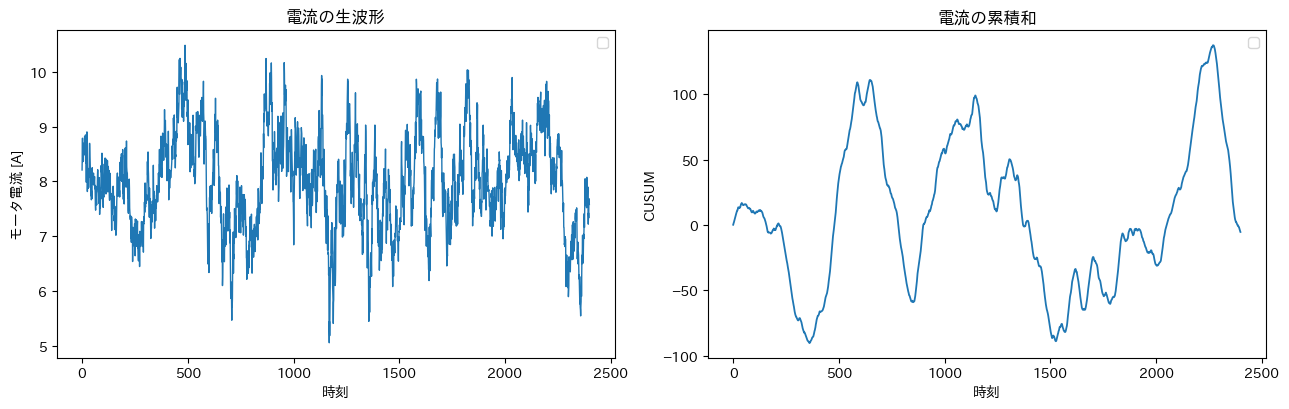

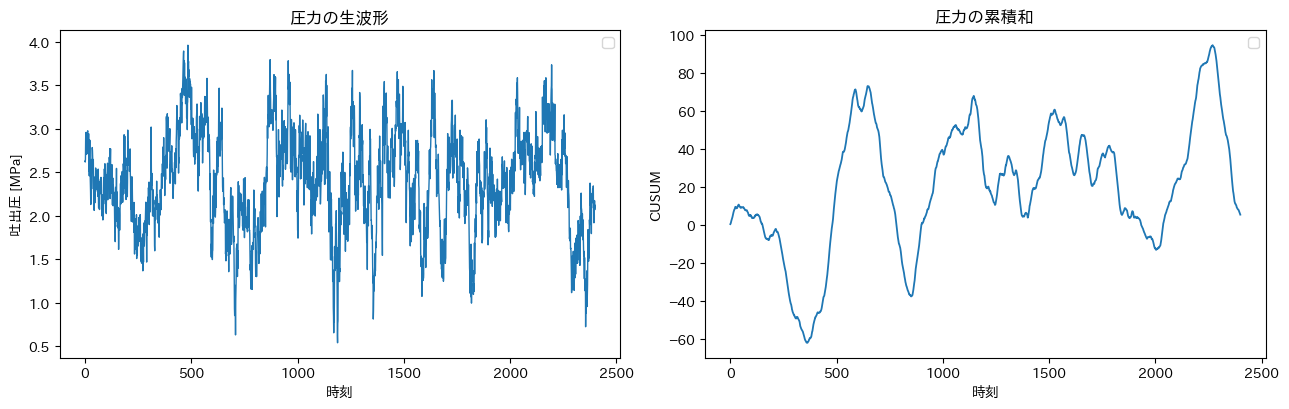

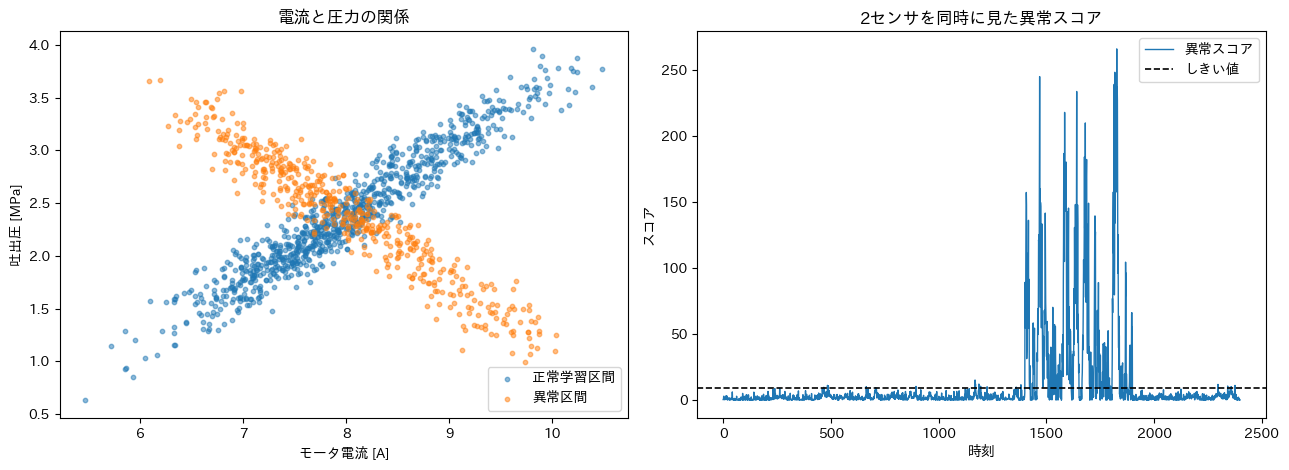

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.covariance import EmpiricalCovariance

# =========================================
# 1. サンプルデータ生成
#    目的:
#    - 各センサ単独では大きく変わらない
#    - 異常区間では 2つのセンサの関係だけ壊れる
#    - その後、正常関係に戻る
# =========================================
def make_segment(n, seed, phi=0.97, eps_scale=0.12):
    """自己相関のある運転負荷 z を作る（平均0、標準偏差1）"""
    rng = np.random.default_rng(seed)
    eps = rng.normal(0, eps_scale, n)
    z = np.zeros(n)
    for i in range(1, n):
        z[i] = phi * z[i - 1] + eps[i]
    z = (z - z.mean()) / z.std()
    return z

# 区間長
n_train = 900
n_test_normal = 500
n_test_abnormal = 500
n_test_recovery = 500

change_index = n_train + n_test_normal
recovery_index = n_train + n_test_normal + n_test_abnormal

# 各区間ごとの運転負荷
z_train = make_segment(n_train, seed=1)
z_test_normal = make_segment(n_test_normal, seed=2)
z_test_abnormal = make_segment(n_test_abnormal, seed=3)
z_test_recovery = make_segment(n_test_recovery, seed=4)

# センサノイズ
rng = np.random.default_rng(123)
noise_current = rng.normal(0, 0.16, n_train + n_test_normal + n_test_abnormal + n_test_recovery)
noise_pressure = rng.normal(0, 0.13, n_train + n_test_normal + n_test_abnormal + n_test_recovery)

# インデックスを切りやすくする
i0 = 0
i1 = n_train
i2 = i1 + n_test_normal
i3 = i2 + n_test_abnormal
i4 = i3 + n_test_recovery

# 電流: 全区間でほぼ同じ関係
current_train = 8.0 + 0.85 * z_train + noise_current[i0:i1]
current_test_normal = 8.0 + 0.85 * z_test_normal + noise_current[i1:i2]
current_test_abnormal = 8.0 + 0.85 * z_test_abnormal + noise_current[i2:i3]
current_test_recovery = 8.0 + 0.85 * z_test_recovery + noise_current[i3:i4]

# 圧力:
# 正常 → 正常 → 異常（関係だけ崩す）→ 正常へ復帰
pressure_train = 2.40 + 0.55 * z_train + noise_pressure[i0:i1]
pressure_test_normal = 2.40 + 0.55 * z_test_normal + noise_pressure[i1:i2]

# 異常区間: 関係だけ崩す
pressure_test_abnormal = 2.40 - 0.55 * z_test_abnormal + noise_pressure[i2:i3]

# 単独平均差が出すぎないように、異常区間の平均を正常へ合わせる
pressure_test_abnormal += pressure_train.mean() - pressure_test_abnormal.mean()

# 復帰区間: 正常な関係に戻す
pressure_test_recovery = 2.40 + 0.55 * z_test_recovery + noise_pressure[i3:i4]

# 全区間を連結
current = np.r_[current_train, current_test_normal, current_test_abnormal, current_test_recovery]
pressure = np.r_[pressure_train, pressure_test_normal, pressure_test_abnormal, pressure_test_recovery]
time = np.arange(len(current))

# =========================================
# 2. 各センサ単独の CUSUM
# =========================================
def cusum_basic(x, baseline_mean):
    return np.cumsum(x - baseline_mean)

cusum_current = cusum_basic(current, current_train.mean())
cusum_pressure = cusum_basic(pressure, pressure_train.mean())

# =========================================
# 3. 2センサを同時に見た異常スコア
# =========================================
X_train = np.column_stack([current_train, pressure_train])
X_all = np.column_stack([current, pressure])

model = EmpiricalCovariance().fit(X_train)
joint_score = model.mahalanobis(X_all)
score_threshold = np.percentile(model.mahalanobis(X_train), 99)

# =========================================
# 4. 可視化用の関数
# =========================================
def plot_raw_and_cusum(raw, cusum, y_raw, title_raw, title_cusum):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

    axes[0].plot(time, raw, linewidth=1.0)
    #axes[0].axvline(change_index, linestyle="--", color="red", linewidth=1.5, label="異常開始")
    #axes[0].axvline(recovery_index, linestyle="--", color="green", linewidth=1.5, label="正常復帰")
    axes[0].set_title(title_raw)
    axes[0].set_xlabel("時刻")
    axes[0].set_ylabel(y_raw)
    axes[0].legend()

    axes[1].plot(time, cusum, linewidth=1.3)
    #axes[1].axvline(change_index, linestyle="--", color="red", linewidth=1.5, label="異常開始")
    #axes[1].axvline(recovery_index, linestyle="--", color="green", linewidth=1.5, label="正常復帰")
    axes[1].set_title(title_cusum)
    axes[1].set_xlabel("時刻")
    axes[1].set_ylabel("CUSUM")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# ---- 電流の生波形と累積和
plot_raw_and_cusum(
    current,
    cusum_current,
    "モータ電流 [A]",
    "電流の生波形",
    "電流の累積和"
)

# ---- 圧力の生波形と累積和
plot_raw_and_cusum(
    pressure,
    cusum_pressure,
    "吐出圧 [MPa]",
    "圧力の生波形",
    "圧力の累積和"
)

# ---- 散布図と異常スコア
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(current_train, pressure_train, s=10, alpha=0.5, label="正常学習区間")
axes[0].scatter(current[change_index:recovery_index], pressure[change_index:recovery_index], s=10, alpha=0.5, label="異常区間")
axes[0].set_title("電流と圧力の関係")
axes[0].set_xlabel("モータ電流 [A]")
axes[0].set_ylabel("吐出圧 [MPa]")
axes[0].legend()

axes[1].plot(time, joint_score, linewidth=1.0, label="異常スコア")
axes[1].axhline(score_threshold, linestyle="--", color="black", linewidth=1.2, label="しきい値")
#axes[1].axvline(change_index, linestyle="--", color="red", linewidth=1.5, label="異常開始")
#axes[1].axvline(recovery_index, linestyle="--", color="green", linewidth=1.5, label="正常復帰")
axes[1].set_title("2センサを同時に見た異常スコア")
axes[1].set_xlabel("時刻")
axes[1].set_ylabel("スコア")
axes[1].legend()

plt.tight_layout()
plt.show()